In [19]:
import gymnasium as gym
import imageio
from pathlib import Path


In [20]:
# Create the FrozenLake environment
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")

output_dir = Path("videos")
output_dir.mkdir(parents=True, exist_ok=True)
video_path = output_dir / "frozen_lake_all_episodes.gif"
frames=[]

# Initialize the environment
state, info = env.reset()

# Number of episodes to simulate
num_episodes = 10

for episode in range(num_episodes):
    print(f"Episode {episode + 1}")
    state, info = env.reset()  # Gymnasium returns (observation, info)
    done = False
    truncated = False

    while not (done or truncated):

        frames.append(env.render())
        # Select a random action
        action = env.action_space.sample()
        # Take the action and observe the outcome
        next_state,reward,done,truncated, info = env.step(action)

        # Print details of the action and result
        print(f"Action: {action}, Next State: {next_state}, Reward: {reward}, Done: {done}")

        # Check if the episode is over
        if done:
            frames.append(env.render())
            if reward == 1:
                print("Reached the goal!")
            else:
                print("Fell into a hole or timed out.")
            break


print(f"Saving all episodes into one GIF: {video_path}")
imageio.mimsave(str(video_path), frames, format="GIF", fps=3)
env.close()


Episode 1
Action: 1, Next State: 4, Reward: 0, Done: False
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 0, Next State: 0, Reward: 0, Done: False
Action: 1, Next State: 4, Reward: 0, Done: False
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 0, Next State: 0, Reward: 0, Done: False
Action: 2, Next State: 1, Reward: 0, Done: False
Action: 1, Next State: 5, Reward: 0, Done: True
Fell into a hole or timed out.
Episode 2
Action: 2, Next State: 1, Reward: 0, Done: False
Action: 1, Next State: 5, Reward: 0, Done: True
Fell into a hole or timed out.
Episode 3
Action: 1, Next State: 4, Reward: 0, Done: False
Action: 2, Next State: 5, Reward: 0, Done: True
Fell into a hole or timed out.
Episode 4
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 3, Next State: 0, Reward: 0, Done: False
Action: 2, Next State: 1, Reward: 0, Done: False
Action: 3, Next State: 1, Reward: 0, 

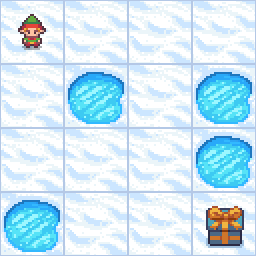

In [18]:
from IPython.display import Image, display
from pathlib import Path

video_path = Path("videos/frozen_lake_all_episodes.gif")
display(Image(filename=str(video_path)))